<a href="https://colab.research.google.com/github/themehmi/Rock-Paper-Scissors-Classifier/blob/main/Rock_Paper_Scissor_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **About Dataset**

The **Rock, Paper, Scissors** dataset is a high-quality synthetic dataset designed by Laurence Moroney specifically for learning and testing Computer Vision models. It is a benchmark for multiclass classification because the images are clean, focused, and well-labeled.

**About Dataset**
Description:
The Rock Paper Scissors Dataset contains a collection of images representing the popular hand game "Rock, Paper, Scissors." The dataset is commonly used for training and evaluating machine learning models, particularly in the field of computer vision and image classification.

**Content**:
The dataset includes images of hands displaying various gestures corresponding to rock, paper, and scissors. Each image is labeled with the corresponding gesture, allowing for supervised learning tasks.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight
import cv2
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Suppresses INFO, WARNING, and ERROR logs

# Data Generators (Preprocessing & Augmentation)
import kagglehub

# Download latest version
path = kagglehub.dataset_download("themehmi/rock-paper-scissors")

print("Path to dataset files:", path)

base_dir = '/root/.cache/kagglehub/datasets/themehmi/rock-paper-scissors/versions/1'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'val')

# Use tf.data for better performance
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
CLASS_NAMES = ['Paper', 'Rock', 'Scissors']

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

# In-model augmentation (avoids CPU bottleneck)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

Using Colab cache for faster access to the 'rock-paper-scissors' dataset.
Path to dataset files: /kaggle/input/rock-paper-scissors
Found 2296 files belonging to 3 classes.
Found 943 files belonging to 3 classes.


# **Model Building & Fine-Tuning**

In [ ]:
# Stage 1: Feature Extraction
base_model = tf.keras.applications.MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(160, 160, 3)),
    layers.Rescaling(1./127.5, offset=-1), # Requirement for MobileNetV2[cite: 1]
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.5), # Prevents overfitting on CGI data[cite: 1]
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_initial = model.fit(train_ds, validation_data=val_ds, epochs=5)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 65s 626ms/step - accuracy: 0.8214 - loss: 0.5214 - val_accuracy: 0.9183 - val_loss: 0.2080
Epoch 2/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 280ms/step - accuracy: 0.9334 - loss: 0.1992 - val_accuracy: 0.9724 - val_loss: 0.0854
Epoch 3/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 244ms/step - accuracy: 0.9512 - loss: 0.1497 - val_accuracy: 0.9841 - val_loss: 0.0503
Epoch 4/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 252ms/step - accuracy: 0.9595 - loss: 0.1115 - val_accuracy: 0.9830 - val_loss: 0.0479
Epoch 5/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - accuracy: 0.9673 - loss: 0.1022 - val_accuracy: 0.9862 - val_loss: 0.0345


In [ ]:
# Stage 2: Fine-Tuning
base_model.trainable = True
# Unfreeze the last 20 layers for specialization[cite: 1]
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=optimizers.Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
history_fine = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 48s 449ms/step - accuracy: 0.9525 - loss: 0.1310 - val_accuracy: 0.9873 - val_loss: 0.0308
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 243ms/step - accuracy: 0.9821 - loss: 0.0489 - val_accuracy: 0.9915 - val_loss: 0.0280
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - accuracy: 0.9856 - loss: 0.0441 - val_accuracy: 0.9905 - val_loss: 0.0196
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - accuracy: 0.9913 - loss: 0.0281 - val_accuracy: 0.9979 - val_loss: 0.0083
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 231ms/step - accuracy: 0.9895 - loss: 0.0327 - val_accuracy: 0.9979 - val_loss: 0.0098
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - accuracy: 0.9882 - loss: 0.0329 - val_accuracy: 0.9979 - val_loss: 0.0023
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 249ms/step - accuracy: 0.9926 - loss: 0.0181 - val_accuracy: 0.9989 - val_loss: 0.0032
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 246ms/step - accuracy: 0.9939 - loss: 0.0196 - val_accu

# **Accuracy Curves & GradCAM Visualisation**

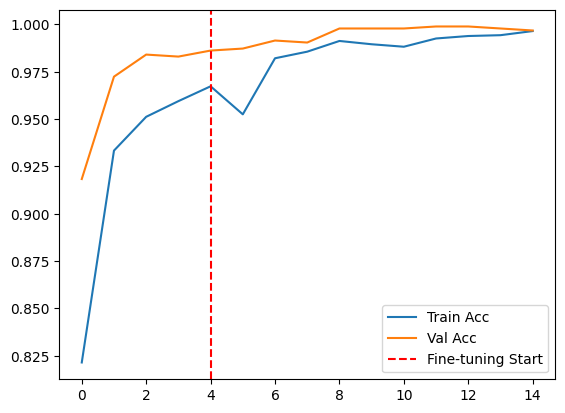

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_8']]
Received: inputs=Tensor(shape=(1, 160, 160, 3))
  warnings.warn(msg)


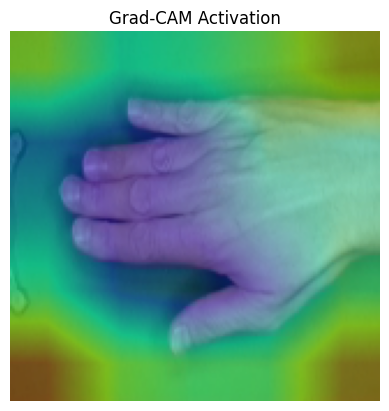

In [ ]:
# Accuracy Curves
acc = history_initial.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_initial.history['val_accuracy'] + history_fine.history['val_accuracy']
plt.plot(acc, label='Train Acc'); plt.plot(val_acc, label='Val Acc')
plt.axvline(x=4, color='r', linestyle='--', label='Fine-tuning Start')
plt.legend(); plt.show()

# Grad-CAM logic (Inline execution)[cite: 1]
img_batch, label_batch = next(iter(val_ds.take(1)))
sample_img = img_batch[0]
img_input = np.expand_dims(sample_img, axis=0)

# Intermediate model to extract gradients
inner_base = model.layers[1]
grad_model = tf.keras.models.Model([inner_base.inputs], [inner_base.get_layer('Conv_1').output, inner_base.output])

with tf.GradientTape() as tape:
    conv_outputs, base_top_outputs = grad_model(img_input)
    # Apply the top layers manually
    preds = base_top_outputs
    for layer in model.layers[2:]:
        preds = layer(preds)
    loss = preds[:, np.argmax(preds[0])]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)

# Overlay
heatmap_resized = cv2.resize(heatmap.numpy(), (160, 160))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
superimposed = cv2.addWeighted(np.uint8(sample_img), 0.6, heatmap_color, 0.4, 0)

plt.imshow(superimposed); plt.title("Grad-CAM Activation"); plt.axis('off'); plt.show()

# **Confusion Matrix**

30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step


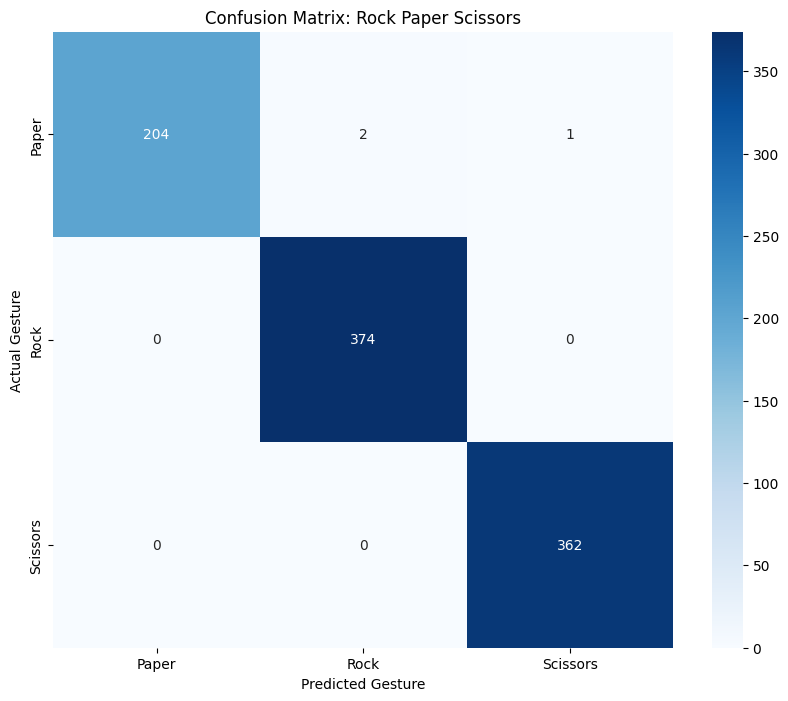

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Extract true labels from the validation dataset
# Since val_ds is a PrefetchDataset, we iterate through it to collect all labels
y_true = []
for images, labels in val_ds:
    # labels are categorical (one-hot), so we take the argmax
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

# Get model predictions
# The model.predict will run through the dataset in the same order
Y_pred = model.predict(val_ds)
y_pred = np.argmax(Y_pred, axis=1)

# Generate the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix: Rock Paper Scissors')
plt.ylabel('Actual Gesture')
plt.xlabel('Predicted Gesture')
plt.show()

In [ ]:
# Save the model in the native Keras format
model.save('rps_model.keras')

Saving images (2).jpg to images (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


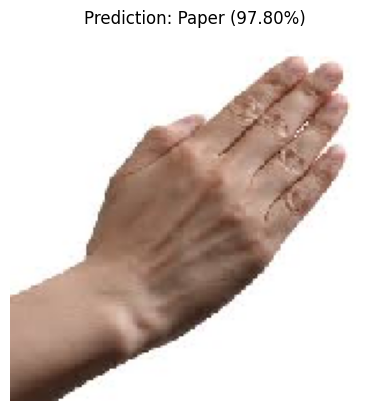

File: images (2).jpg
Top Class: Paper
Confidence: 97.80%


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import files
from tensorflow.keras.preprocessing import image

# Define Constants
IMG_SIZE = (160, 160)
CLASS_NAMES = ['Paper', 'Rock', 'Scissors'] # From rock_paper_scissor_classifier.py

def predict_uploaded_image():
    # Trigger file upload
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Load and preprocess the image
        # Note: MobileNetV2 requires 160x160 input
        img_path = filename
        img = image.load_img(img_path, target_size=IMG_SIZE)
        img_array = image.img_to_array(img)
        img_batch = np.expand_dims(img_array, axis=0)

        # Inference
        # The model includes the rescaling layer (-1 to 1)
        predictions = model.predict(img_batch)
        score = tf.nn.softmax(predictions[0])
        class_idx = np.argmax(predictions[0])
        confidence = 100 * np.max(predictions[0])

        # Visualization
        plt.imshow(img)
        plt.title(f"Prediction: {CLASS_NAMES[class_idx]} ({confidence:.2f}%)")
        plt.axis('off')
        plt.show()

        print(f"File: {filename}")
        print(f"Top Class: {CLASS_NAMES[class_idx]}")
        print(f"Confidence: {confidence:.2f}%")

# Run the function
predict_uploaded_image()

In [ ]:
#TensorFlow Lite Model
import tensorflow as tf

# Load your saved model
model = tf.keras.models.load_model('rps_model.keras')

# Initialize the TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optional: Apply optimization (Quantization) to reduce size (e.g., from 10MB to 2.5MB)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_model = converter.convert()

# Save the .tflite file
with open('rps_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("TFLite model saved successfully!")

Saved artifact at '/tmp/tmpx1ymj_j6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133238477841872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133238477833040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133238477833616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133238477836880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133238477833808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133238477832272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133238477847632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133238477843600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133238477844176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133238477841104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1332384778364